<a href="https://colab.research.google.com/github/afullhart/SantaRita/blob/main/Sims/minimal_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f

### Function wrappers

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_main_array(target_bg, plot_radius=55, cell_size=0.05):
    """
    Generates the synthesized main_array ground cover simulation.
    Updated with Exponential Decay Z-Indexed Hybrid Logic.

    Parameters:
    - target_bg: The target bare ground percentage (0-100).
    - plot_radius: The radius of the simulated plot in meters.
    - cell_size: The resolution of the grid in meters.

    Returns:
    - main_array: 2D numpy array representing the simulated ground cover.
    """

    # ==========================================
    # 1. GRID INITIALIZATION
    # ==========================================
    x = np.arange(-plot_radius, plot_radius + (cell_size * 0.1), cell_size)
    y = np.arange(-plot_radius, plot_radius + (cell_size * 0.1), cell_size)
    grid_size = len(x)
    X, Y = np.meshgrid(x, y)

    dist_from_center = np.sqrt(X**2 + Y**2)
    valid_mask = dist_from_center <= plot_radius
    total_valid_pixels = np.count_nonzero(valid_mask)

    large_shrub_value = 1
    small_shrub_value = 2
    target_value = 3

    # ==========================================
    # 2. Z-INDEXED HYBRID LOGIC (EXPONENTIAL DECAY)
    # ==========================================
    organic_weight = 0.60
    organic_bg_pct = target_bg * organic_weight

    initial_veg_coverage = (100.0 - target_bg) / (100.0 - organic_bg_pct)
    base_lambda = -np.log(1 - initial_veg_coverage) if initial_veg_coverage < 0.99 else 5.0

    # Calculate how much extra boost we need at the absolute lowest BG
    boost_amount = max(0.0, 6.5 - base_lambda)

    # 1. PRESERVE ORIGINAL WOODY CURVE (Decays rapidly by ~12% BG)
    woody_decay = np.exp(-target_bg / 4.0)
    lambda_woody_base = base_lambda + (boost_amount * woody_decay)

    # 2. ENSURE ENOUGH PUNCHABLE COVER (Decays smoothly by ~40% BG)
    total_decay = np.exp(-target_bg / 12.0)
    lambda_total = base_lambda + (boost_amount * total_decay)

    alpha_large = 0.75

    # 3. Calculate Large (Woody)
    lambda_large = lambda_woody_base * alpha_large

    # 4. Calculate Small (Herbaceous)
    lambda_small = lambda_total - lambda_large

    r_large_bnds = (0.3, 2.0)
    r_small_bnds = (0.10, 0.30)

    mean_area_large = np.pi * ((r_large_bnds[0]**2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]**2) / 3.0)
    mean_area_small = np.pi * ((r_small_bnds[0]**2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]**2) / 3.0)

    plot_area = np.pi * (plot_radius**2)
    num_large = int(lambda_large * (plot_area / mean_area_large))
    num_small = int(lambda_small * (plot_area / mean_area_small))

    if target_bg <= 50:
        prob_dark = np.interp(target_bg, [5, 50], [0.05, 0.45])
    else:
        prob_dark = np.interp(target_bg, [50, 100], [0.45, 1.0])

    # ==========================================
    # 3. DECOUPLED SPATIAL PROCESSES & PATCH SHAPING
    # ==========================================
    cluster_spread = np.interp(target_bg, [0, 100], [8.0, 1.0])

    # Use floats for smooth scaling to prevent integer step-function variance spikes
    shrubs_per_cluster_float = np.interp(target_bg, [0, 100], [2.0, 10.0])
    num_parents = max(1, int(num_large / shrubs_per_cluster_float)) if num_large > 0 else 0

    large_mask = np.zeros((grid_size, grid_size), dtype=bool)
    small_mask = np.zeros((grid_size, grid_size), dtype=bool)

    shadow_angle = np.radians(135)
    shadow_dx = np.cos(shadow_angle)
    shadow_dy = np.sin(shadow_angle)

    # --- Large Shrubs: Dynamic Thomas Cluster ---
    if num_parents > 0:
        gen_radius = plot_radius + r_large_bnds[1] + cluster_spread
        r_parents = gen_radius * np.sqrt(np.random.uniform(0, 1, num_parents))
        theta_parents = np.random.uniform(0, 2 * np.pi, num_parents)
        px_arr = r_parents * np.cos(theta_parents)
        py_arr = r_parents * np.sin(theta_parents)

        is_woody_parent = np.random.rand(num_parents) <= prob_dark

        if num_large > 0:
            r_large_arr = np.random.uniform(r_large_bnds[0], r_large_bnds[1], num_large)
            parent_indices = np.random.randint(0, num_parents, num_large)
            cx_arr = np.random.normal(px_arr[parent_indices], cluster_spread)
            cy_arr = np.random.normal(py_arr[parent_indices], cluster_spread)

            for i, rad in enumerate(r_large_arr):
                cx = cx_arr[i]
                cy = cy_arr[i]

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                dot_prod = (dx * shadow_dx + dy * shadow_dy) / (r_grid + 1e-5)
                shadow_intensity = np.clip(dot_prod, 0, 1)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(3, 6)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.4, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                norm_dist = np.clip((r_grid - r_core) / rad, 0, 1)
                porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ** 1.5)
                fringe_keep_mask = np.random.rand(*dx.shape) > porosity_chance
                lobe_mask &= fringe_keep_mask

                if is_woody_parent[parent_indices[i]]:
                    large_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)
                else:
                    small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # --- Small Shrubs: Thomas Cluster ---
    if num_small > 0:
        shrubs_per_cluster_small_float = np.interp(target_bg, [0, 100], [5.0, 20.0])
        num_parents_small = max(1, int(num_small / shrubs_per_cluster_small_float))
        cluster_spread_small = cluster_spread * 0.80

        if num_parents_small > 0:
            gen_radius_small = plot_radius + r_small_bnds[1] + cluster_spread_small
            r_parents_s = gen_radius_small * np.sqrt(np.random.uniform(0, 1, num_parents_small))
            theta_parents_s = np.random.uniform(0, 2 * np.pi, num_parents_small)
            px_arr_s = r_parents_s * np.cos(theta_parents_s)
            py_arr_s = r_parents_s * np.sin(theta_parents_s)

            r_small_arr = np.random.uniform(r_small_bnds[0], r_small_bnds[1], num_small)
            parent_indices_s = np.random.randint(0, num_parents_small, num_small)
            cx_arr_s = np.random.normal(px_arr_s[parent_indices_s], cluster_spread_small)
            cy_arr_s = np.random.normal(py_arr_s[parent_indices_s], cluster_spread_small)

            for i, rad in enumerate(r_small_arr):
                cx = cx_arr_s[i]
                cy = cy_arr_s[i]

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(2, 5)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.3, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # ==========================================
    # 4. ASSEMBLE GRID & FRACTAL NOISE PUNCHING
    # ==========================================
    main_array = np.full((grid_size, grid_size), target_value, dtype=int)
    main_array[small_mask] = small_shrub_value
    main_array[large_mask] = large_shrub_value

    target_bare_pixels = int(total_valid_pixels * (target_bg / 100.0))
    current_bare_pixels = np.count_nonzero((main_array == target_value) & valid_mask)
    pixels_to_punch = target_bare_pixels - current_bare_pixels

    if pixels_to_punch > 0:
        punchable_mask = small_mask & ~large_mask & valid_mask
        punchable_count = np.count_nonzero(punchable_mask)

        if pixels_to_punch >= punchable_count:
            main_array[punchable_mask] = target_value
        else:
            raw_fine = np.random.rand(grid_size, grid_size)
            raw_coarse = np.random.rand(grid_size, grid_size)

            blurred_fine = gaussian_filter(raw_fine, sigma=(1.00 / cell_size))
            blurred_coarse = gaussian_filter(raw_coarse, sigma=(3.00 / cell_size))

            fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

            punchable_noise = fractal_noise[punchable_mask]
            fraction_to_punch = pixels_to_punch / punchable_count
            threshold = np.percentile(punchable_noise, (1 - fraction_to_punch) * 100)

            hole_mask = punchable_mask & (fractal_noise >= threshold)
            main_array[hole_mask] = target_value

    # Mask out the circular area boundary
    main_array[~valid_mask] = -9999

    return main_array

# Example execution
final_array = generate_main_array(target_bg=50)

### Viz

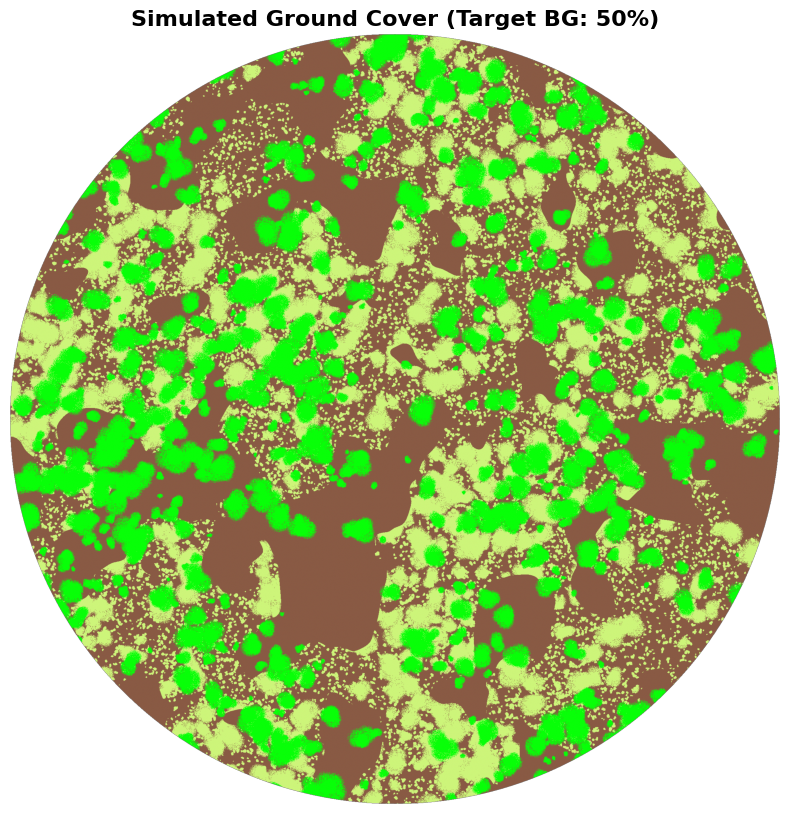

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Generate the array
final_array = generate_main_array(target_bg=50)

# Replace the -9999 out-of-bounds mask with NaN so it plots as a blank background
plot_array = np.where(final_array == -9999, np.nan, final_array)

# Set up the visualization
plt.figure(figsize=(10, 10))

# Custom colormap using your exact hex and xkcd codes
cmap = mcolors.ListedColormap(['xkcd:fluorescent green', '#CDF57A', '#895A44'])
norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

# Display the plot
plt.imshow(plot_array, cmap=cmap, norm=norm, origin='lower')
plt.title("Simulated Ground Cover (Target BG: 50%)", fontsize=16, weight='bold')
plt.axis('off')
plt.show()


### Pseudo Code

In [ ]:
# =====================================================================
# HYPOTHETICAL FUNCTION GLOSSARY
# =====================================================================
# UniformRandom(min, max): Draws random value(s) from a continuous uniform distribution.
# NormalRandom(mean, std_dev): Draws random value(s) from a Gaussian (Normal) distribution.
# RandomInteger(min, max): Draws a random integer inclusive of bounds.
# Interpolate(value, x_range, y_range): Performs linear interpolation.
# Exponential(value): Returns Euler's number (e) raised to the power of the value.
# DistanceGrid(center_x, center_y): Returns a 2D array of Euclidean distances from a given point.
# GaussianFilter(array, sigma): Applies a 2D Gaussian blur with a specified standard deviation.
# Percentile(array, p): Returns the p-th percentile value of an array.
# CalculateDotProduct(grid, dx, dy): Returns the normalized directional dot product.
# Clamp(value, min, max): Restricts a value to be within a specific min and max range.
# Floor(value): Rounds a number down to the nearest integer.
# Max(a, b): Returns the largest of the given values.
# =====================================================================

FUNCTION Generate_Ground_Cover(target_bgr, plot_radius, cell_size):

    # ==========================================
    # STEP 1: POPULATION SIZING (EXPONENTIAL DECAY HYBRID LOGIC)
    # ==========================================
    organic_bgr_pct = target_bgr * 0.60
    initial_veg_coverage = (100.0 - target_bgr) / (100.0 - organic_bgr_pct)

    # Calculate Poisson Point Process base lambda
    IF initial_veg_coverage < 0.99:
        base_lambda = -NaturalLog(1 - initial_veg_coverage)
    ELSE:
        base_lambda = 5.0

    # Calculate required spatial overlap boost for absolute lowest BGR
    boost_amount = Max(0.0, 6.5 - base_lambda)

    # 1. Preserve original woody curve (Decays rapidly by ~12% BGR)
    woody_decay = Exponential(-target_bgr / 4.0)
    lambda_woody_base = base_lambda + (boost_amount * woody_decay)

    # 2. Ensure enough punchable herbaceous cover (Decays smoothly by ~40% BGR)
    total_decay = Exponential(-target_bgr / 12.0)
    lambda_total = base_lambda + (boost_amount * total_decay)

    # Split densities
    lambda_large = lambda_woody_base * 0.75
    lambda_small = lambda_total - lambda_large

    r_large_bnds = [0.3, 2.0]
    r_small_bnds = [0.10, 0.30]

    # Calculate expected mean area of a circle with uniform random radius (using float denominators)
    mean_area_large = Pi * ((r_large_bnds[0]^2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]^2) / 3.0)
    mean_area_small = Pi * ((r_small_bnds[0]^2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]^2) / 3.0)

    plot_area = Pi * (plot_radius^2)
    num_large_patches = Floor(lambda_large * (plot_area / mean_area_large))
    num_small_patches = Floor(lambda_small * (plot_area / mean_area_small))

    # Determine dynamic survival probability for woody cover reclassification
    IF target_bgr <= 50:
        woody_survival_prob = Interpolate(target_bgr, x_range=[5, 50], y_range=[0.05, 0.45])
    ELSE:
        woody_survival_prob = Interpolate(target_bgr, x_range=[50, 100], y_range=[0.45, 1.0])

    # ==========================================
    # STEP 2: SPATIAL CLUSTERING (THOMAS PROCESS)
    # ==========================================
    clust_spread = Interpolate(target_bgr, x_range=[0, 100], y_range=[8.0, 1.0])

    # Use floats for smooth scaling to prevent integer step-function variance spikes
    shrubs_per_cluster_float = Interpolate(target_bgr, x_range=[0, 100], y_range=[2.0, 10.0])
    num_parents = Max(1, Floor(num_large_patches / shrubs_per_cluster_float))

    # Generate Parent Cluster Centers (using Complete Spatial Randomness)
    parent_x_coords = []
    parent_y_coords = []
    parent_is_woody = []

    FOR i FROM 1 TO num_parents:
        parent_radius = SquareRoot(UniformRandom(0, 1)) * (plot_radius + r_large_bnds[1] + clust_spread)
        parent_theta = UniformRandom(0, 2 * Pi)
        parent_x_coords.append(parent_radius * Cosine(parent_theta))
        parent_y_coords.append(parent_radius * Sine(parent_theta))

        # Decide if this parent cluster survives as woody cover or becomes herbaceous
        IF UniformRandom(0, 1) <= woody_survival_prob:
            parent_is_woody.append(True)
        ELSE:
            parent_is_woody.append(False)

    # Initialize empty 2D spatial Boolean masks
    large_patch_mask = CreateBlankBooleanGrid()
    small_patch_mask = CreateBlankBooleanGrid()

    # ==========================================
    # STEP 3A: PATCH SHAPING
    # ==========================================
    # Set shadow vector for directional porosity at 135 degrees
    shadow_dx = Cosine(135 degrees)
    shadow_dy = Sine(135 degrees)

    # Distribute and shape large patches
    FOR patch FROM 1 TO num_large_patches:
        parent_idx = RandomInteger(1, num_parents)
        patch_radius = UniformRandom(r_large_bnds[0], r_large_bnds[1])

        # Stage 1: Gaussian placement around parent center
        center_x = NormalRandom(mean=parent_x_coords[parent_idx], std_dev=clust_spread)
        center_y = NormalRandom(mean=parent_y_coords[parent_idx], std_dev=clust_spread)
        dist_grid = DistanceGrid(center_x, center_y)

        # Stage 2: Inner Core with Edge Noise
        r_core = patch_radius * 0.60
        core_noise = UniformRandom(-0.15, 0.15, grid_size)
        core_mask = (dist_grid <= r_core * (1.0 + core_noise))

        # Stage 3: Overlapping Lobes
        lobe_mask = CreateBlankBooleanGrid()
        num_lobes = RandomInteger(3, 6) # Updated max lobes to 6 based on new code
        FOR lobe FROM 1 TO num_lobes:
            lobe_angle = UniformRandom(0, 2 * Pi)
            lobe_offset = patch_radius * UniformRandom(0.3, 0.7)
            lobe_x = center_x + (lobe_offset * Cosine(lobe_angle))
            lobe_y = center_y + (lobe_offset * Sine(lobe_angle))
            lobe_radius = patch_radius * UniformRandom(0.4, 0.8)
            lobe_noise = UniformRandom(-0.20, 0.20, grid_size)

            lobe_dist_grid = DistanceGrid(lobe_x, lobe_y)
            lobe_mask = lobe_mask OR (lobe_dist_grid <= lobe_radius * (1.0 + lobe_noise))

        # Stage 4: Directional Porosity (Canopy Gaps)
        shadow_intensity = Clamp(CalculateDotProduct(dist_grid, shadow_dx, shadow_dy), min=0, max=1)
        norm_dist = Clamp((dist_grid - r_core) / patch_radius, min=0, max=1)

        porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ^ 1.5)
        keep_mask = (UniformRandom(0, 1, grid_size) > porosity_chance)

        # Subtractive filter applied to lobes, then unioned with core
        lobe_mask = lobe_mask AND keep_mask
        composite_patch = core_mask OR lobe_mask

        # Assign to final arrays based on reclassification filter
        IF parent_is_woody[parent_idx] == True:
            large_patch_mask = large_patch_mask OR composite_patch
        ELSE:
            small_patch_mask = small_patch_mask OR composite_patch

    # ==========================================
    # STAGE 3B: SMALL PATCH SHAPING
    # ==========================================
    # The exact 4-stage shaping process above is repeated for small patches
    # (FOR patch FROM 1 TO num_small_patches), substituting the following
    # parameters to create denser, smaller herbaceous clusters:

    shrubs_per_cluster_small_float = Interpolate(target_bgr, x_range=[0, 100], y_range=[5.0, 20.0])
    num_parents_small = Max(1, Floor(num_small_patches / shrubs_per_cluster_small_float))
    small_patch_spread = clust_spread * 0.80
    small_patch_lobes = RandomInteger(2, 5)
    small_patch_lobe_radius = patch_radius * UniformRandom(0.3, 0.8)

    # ==========================================
    # STEP 4: PATCH SUBTRACTION (FRACTAL NOISE)
    # ==========================================
    # Determine exact number of herbaceous pixels to remove
    target_bare_pixels = TotalPlotPixels * (target_bgr / 100.0)
    current_bare_pixels = CountPixels(NOT small_patch_mask AND NOT large_patch_mask)
    pixels_to_remove = target_bare_pixels - current_bare_pixels

    # Establish vulnerability mask (only herbaceous cover can be subtracted)
    punchable_mask = small_patch_mask AND NOT large_patch_mask

    IF pixels_to_remove > 0 AND pixels_to_remove < CountPixels(punchable_mask):

        # Generate independent continuous uniform noise arrays
        raw_fine_noise = UniformRandom(0, 1, grid_size)
        raw_coarse_noise = UniformRandom(0, 1, grid_size)

        # Apply Gaussian kernels (Sigma acts as spatial radius divided by cell size)
        blurred_fine = GaussianFilter(raw_fine_noise, sigma=(1.00 / cell_size))
        blurred_coarse = GaussianFilter(raw_coarse_noise, sigma=(3.00 / cell_size))

        # Assemble composite fractal topography map
        fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

        # Determine removal threshold based strictly on vulnerable herbaceous pixels
        frac_to_rem = pixels_to_remove / CountPixels(punchable_mask)
        threshold = Percentile(fractal_noise[punchable_mask], (1.0 - frac_to_rem) * 100.0)

        # Identify topographically high peaks
        bare_ground_gaps = punchable_mask AND (fractal_noise >= threshold)

        # Subtract gaps from the herbaceous layer
        small_patch_mask = small_patch_mask AND NOT bare_ground_gaps

    # ==========================================
    # ASSEMBLE FINAL SIMULATION
    # ==========================================
    main_array = CreateBlankGrid(background_value=3)
    main_array[small_patch_mask] = 2  # Herbaceous Code
    main_array[large_patch_mask] = 1  # Woody Code

    RETURN main_array